                                                     text  generated
419952  Real or Fake Feelings\n\n"Imagine being able t...        0.0
478535  Seeking multiple opinions can help you make be...        0.0
133753  ADDRESS_NAME\n\nFebruary 9, 2011\n\nDear TEACH...        0.0
68011   Dear, TEACHER_NAME,\n\nTEACHER_NAME I Believe ...        0.0
195939  Do you believe that there is a computer that c...        0.0
Accuracy: 0.97675
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98      2482
         1.0       0.98      0.96      0.97      1518

    accuracy                           0.98      4000
   macro avg       0.98      0.97      0.98      4000
weighted avg       0.98      0.98      0.98      4000



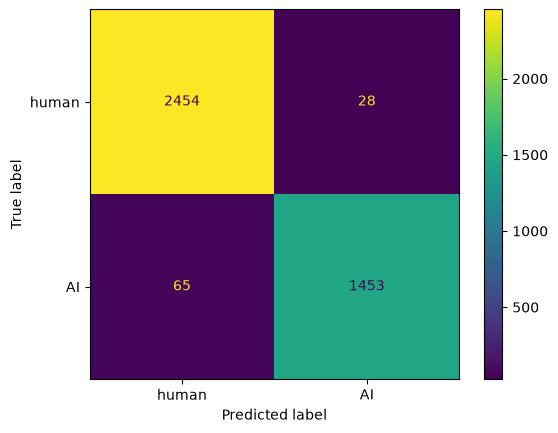

AI


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Load data (upload the CSV to Colab first)
df = pd.read_csv("AI_Human.csv")
df = df.sample(20000, random_state=42)
print(df.head())   # check column names

# 2. Change these to match your columns
X = df["text"]
y = df["generated"]    # 0 = human, 1 = AI

# 3. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 4. Text -> numbers (TF-IDF)
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# 5. Train
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# 6. Evaluate
pred = model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

# 7. Try your own text
ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                      display_labels=["human","AI"]).plot()
plt.show()
sample = ["Artificial intelligence has revolutionized numerous industries ."]
print("AI" if model.predict(tfidf.transform(sample))[0] == 1 else "Human")